In [54]:
from methylseqnet import dna_io, inference
from dimelo import load_processed, plot_enrichment_profile
from matplotlib import pyplot as plt
import torch
import numpy as np

In [38]:
ref_genome = '/clusterfs/nilah/oberon/jupyter/chm13.draft_v1.0.fasta'
CpG_pileup = '/clusterfs/nilah/oberon/datasets/deep_ctcf/cpg_bam_whole_genome/pileup.sorted.bed.gz'
mA_pileup = '/clusterfs/nilah/oberon/datasets/deep_ctcf/allcontext_bam_whole_genome/pileup.sorted.bed.gz'

In [50]:
pileup_hp1 = '/clusterfs/nilah/oberon/datasets/deep_ctcf/phased/chrX_hp1_processed/pileup.sorted.bed.gz'
pileup_hp2 = '/clusterfs/nilah/oberon/datasets/deep_ctcf/phased/chrX_hp2_processed/pileup.sorted.bed.gz'

In [4]:
model_paths = [
    '/clusterfs/nilah/oberon/datasets/methylseq-net_deep-ctcf/models/bd417dd_2024-05-20_14-12-34_in4',
    '/clusterfs/nilah/oberon/datasets/methylseq-net_deep-ctcf/models/bd417dd_2024-05-20_14-13-35_in5',
    '/clusterfs/nilah/oberon/datasets/methylseq-net_deep-ctcf/models/bd417dd_2024-05-20_14-33-39_in1',
]

In [5]:
models = [inference.load_for_eval(model_path) for model_path in model_paths]

In [6]:
chromosome = 'chrX'
start = 130064000
end = 130080000

In [82]:
onehot_inputs = []
onehot_hp1 = []
onehot_hp2 = []
for chunk_start in range(start,end,128):
    onehot_inputs.append(
        dna_io.one_hot_dna_from_file(
            chromosome=chromosome,
            start=chunk_start,
            end=chunk_start + 896,
            ref_genome=ref_genome,
            cpg=True,
            cpg_bedmethyl=CpG_pileup,
        )
    )
    onehot_hp1.append(
        dna_io.one_hot_dna_from_file(
            chromosome=chromosome,
            start=chunk_start,
            end=chunk_start + 896,
            ref_genome=ref_genome,
            cpg=True,
            cpg_bedmethyl=pileup_hp1,
        )
    )
    onehot_hp2.append(
        dna_io.one_hot_dna_from_file(
            chromosome=chromosome,
            start=chunk_start,
            end=chunk_start + 896,
            ref_genome=ref_genome,
            cpg=True,
            cpg_bedmethyl=pileup_hp2,
        )
    )

<Axes: xlabel='pos', ylabel='fraction modified bases'>

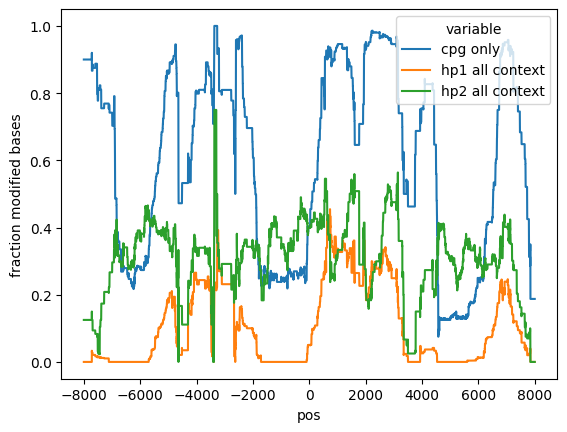

In [73]:
region = f'{chromosome}:{start}-{end}'
plot_enrichment_profile.plot_enrichment_profile(
    mod_file_names = [CpG_pileup,pileup_hp1,pileup_hp2],
    regions_list = [region,region,region],
    sample_names = ['cpg only','hp1 all context','hp2 all context'],
    motifs = ['CG,0','CG,0','CG,0'],
    window_size = None,
    smooth_window = 600,
)
# samtools view -N qnames_list.txt -o filtered_output.bam input.bam, requires samtools 1.12 or greater

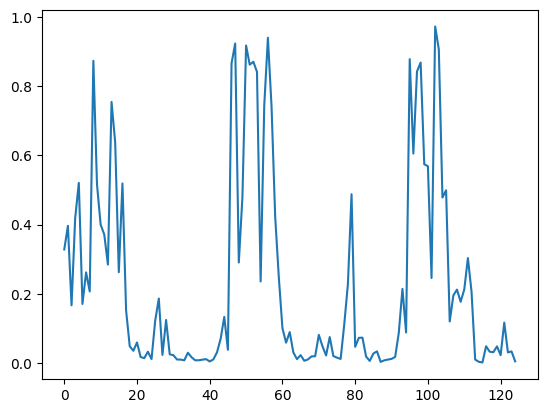

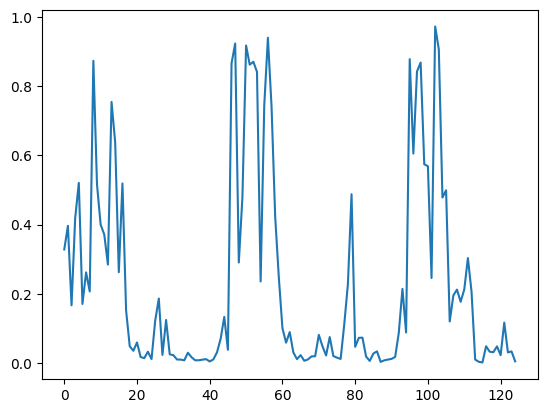

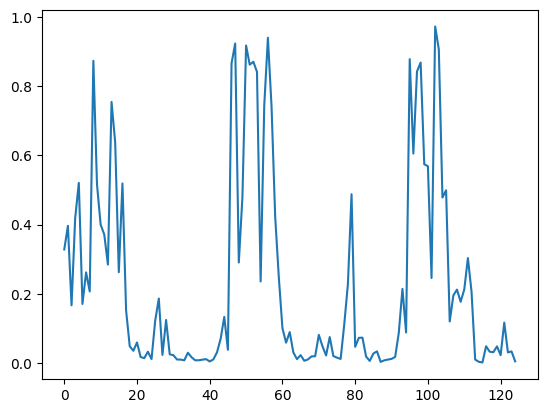

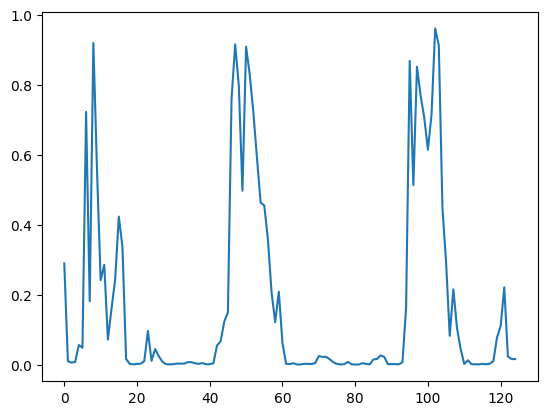

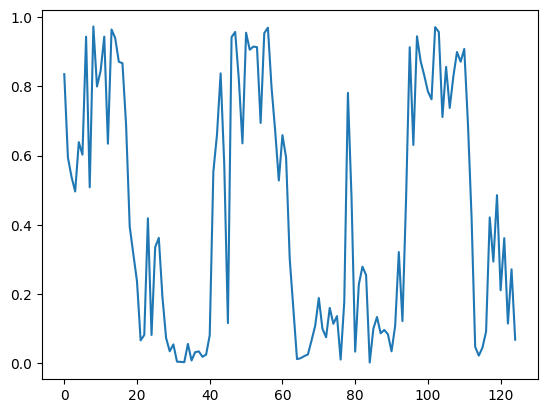

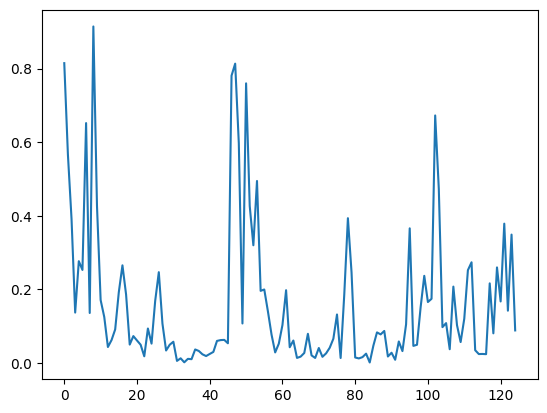

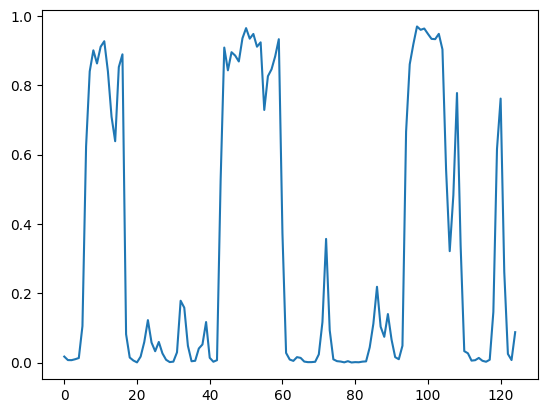

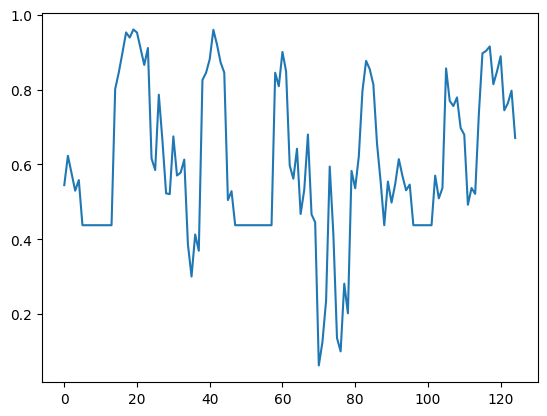

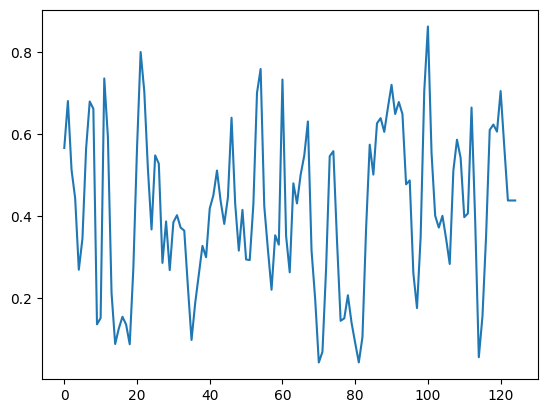

In [83]:
# print(np.array(onehot_hp2).shape)
# print(np.array(onehot_hp2).shape)
onehot_hp2 = np.array(onehot_hp2)
# onehot_hp2[:,:,-1] = 0.7
for model in models:
    for onehot in [onehot_inputs,onehot_hp1,onehot_hp2]:
        predictions = torch.sigmoid(model(torch.tensor(np.transpose(np.array(onehot), (0,2,1)),dtype=torch.float32)).detach())
        plt.plot(np.array(predictions))
        plt.show()

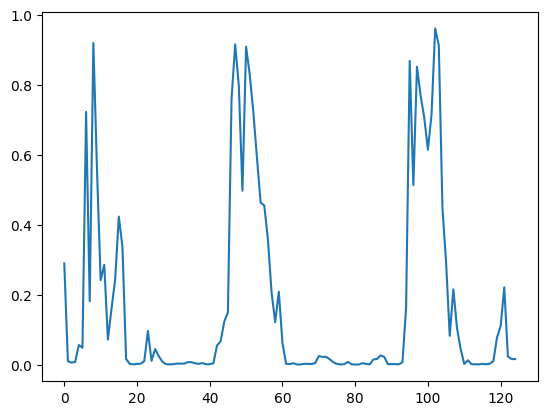